If close to normal distribution, anything with mod(z)>3 is outlier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('placements.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


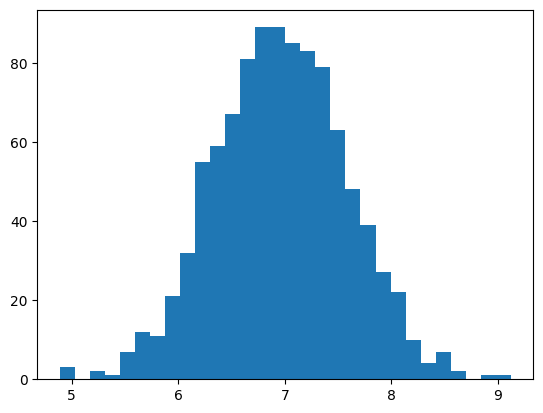

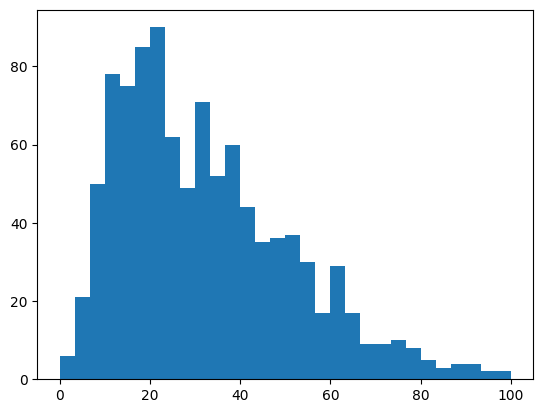

In [3]:
plt.hist(df['cgpa'],bins=30)
plt.show()
plt.hist(df['placement_exam_marks'],bins=30)
plt.show()

We can apply Z-score method only on cgpa col as its normally distributed

<Axes: ylabel='cgpa'>

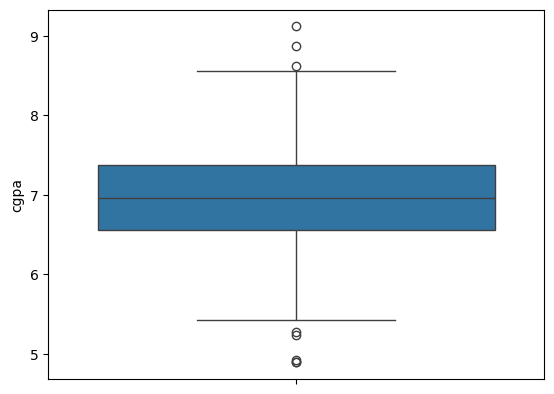

In [4]:
sns.boxplot(df['cgpa'])

In [5]:
print("FOR cgpa:")
print("Mean",df['cgpa'].mean())
print("Std value",df['cgpa'].std())
print("Min value",df['cgpa'].min())
print("Max value",df['cgpa'].max())

FOR cgpa:
Mean 6.96124
Std value 0.6158978751323894
Min value 4.89
Max value 9.12


In [6]:
print("Upper boundary",df['cgpa'].mean()+3*df['cgpa'].std())
print("Lowwer boundary",df['cgpa'].mean()-3*df['cgpa'].std())

Upper boundary 8.808933625397168
Lowwer boundary 5.113546374602832


In [7]:
df[(df['cgpa']>8.80) | (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [8]:
new_df=df[(df['cgpa']<8.80) & (df['cgpa']>5.11)]
new_df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<h3><b> 2nd approach

In [10]:
df['cgpa_zscore']=(df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [11]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [15]:
df[(df['cgpa_zscore']>3) | (df['cgpa_zscore']<-3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [16]:
new_df=df[(df['cgpa_zscore']<3) & (df['cgpa_zscore']>-3)]
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


<h3><b>Capping

In [17]:
upper=df['cgpa'].mean()+3*df['cgpa'].std()
lower=df['cgpa'].mean()-3*df['cgpa'].std()
upper,lower

(np.float64(8.808933625397168), np.float64(5.113546374602832))

In [19]:
df['cgpa']=np.where(df['cgpa']>upper,upper,
                    np.where(df['cgpa']<lower,lower,df['cgpa']))

In [22]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64